# Question 0

In [11]:
import pandas as pd

df = pd.read_csv('accounts.csv')
cut_df = df.iloc[:,:8]
cut_df.drop_duplicates()

df_dummies = pd.get_dummies(cut_df, drop_first=True)

# Question 1

# a)

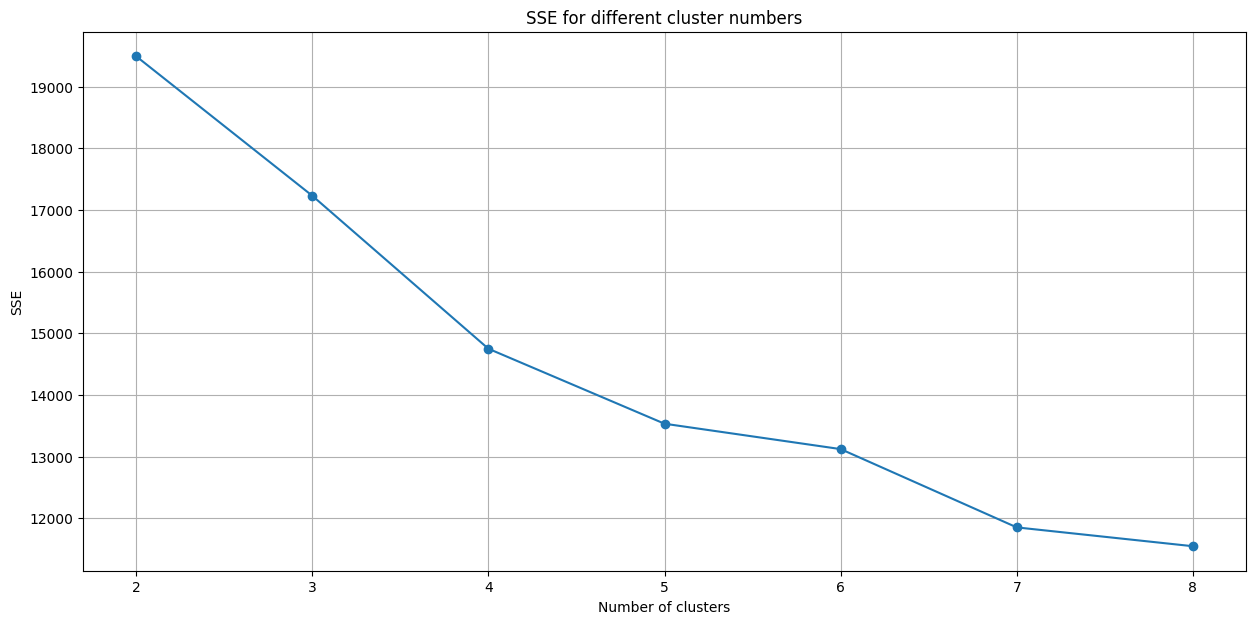

In [13]:
from sklearn.preprocessing import MinMaxScaler
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

scaler = MinMaxScaler()
normalized_data = scaler.fit_transform(df_dummies)

sse = []
for k in range(2, 9):
    kmeans_algo = KMeans(n_clusters=k, max_iter=500, random_state=42)
    kmeans_model = kmeans_algo.fit(normalized_data)
    sse.append(kmeans_model.inertia_)

# Plotting
plt.figure(figsize=(15, 7))
plt.plot(range(2, 9), sse, marker='o')
plt.title('SSE for different cluster numbers')
plt.xlabel('Number of clusters')
plt.ylabel('SSE')
plt.grid(True)
plt.show()

# b)

Aumentando o número de clusters, diminui-se a inertia (SSE) e aumenta-se a proximidade dos pontos do cluster ao centróide, aumentando a performance do modelo. No entanto, aumentar demasiado o número de clusters pode causar overfitting, logo, é necessário encontrar o ponto de balanço entre a inertia e o número de clusters.
Analisando o gráfico, podemos observar que o ponto a partir de qual a inertia começa a descer mais lentamente é nos 4 clusters. Sendo assim, aumentar o número de clusters não vai trazer uma grande melhoria em performance mas pode levar a overfitting. Logo, é seguro dizer que o número ideal de clusters é 4.

# c)

Ambas approaches requerem conversões de variáveis do CSV original. A approach k-modes requeria converter as variáveis "age" e "balance" parecendo assim a melhor approach pois requer apenas 2 conversões, ao contrário de k-means que necessitaria de 6 conversões de variáveis. No entanto, num dataset com as variáveis binárias mapeadas a valores numéricos, a approach k-means seria a melhor por ter de converter apenas 3 variáveis.

# Question 2

# a)

In [15]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

scaler = StandardScaler()
normalized_data = scaler.fit_transform(df_dummies)

pca = PCA(n_components=2)
pca.fit(normalized_data)

explained_variance = pca.explained_variance_ratio_
print(f'Explained variance = {explained_variance}')

Explained variance = [0.11825412 0.11127853]


# b)

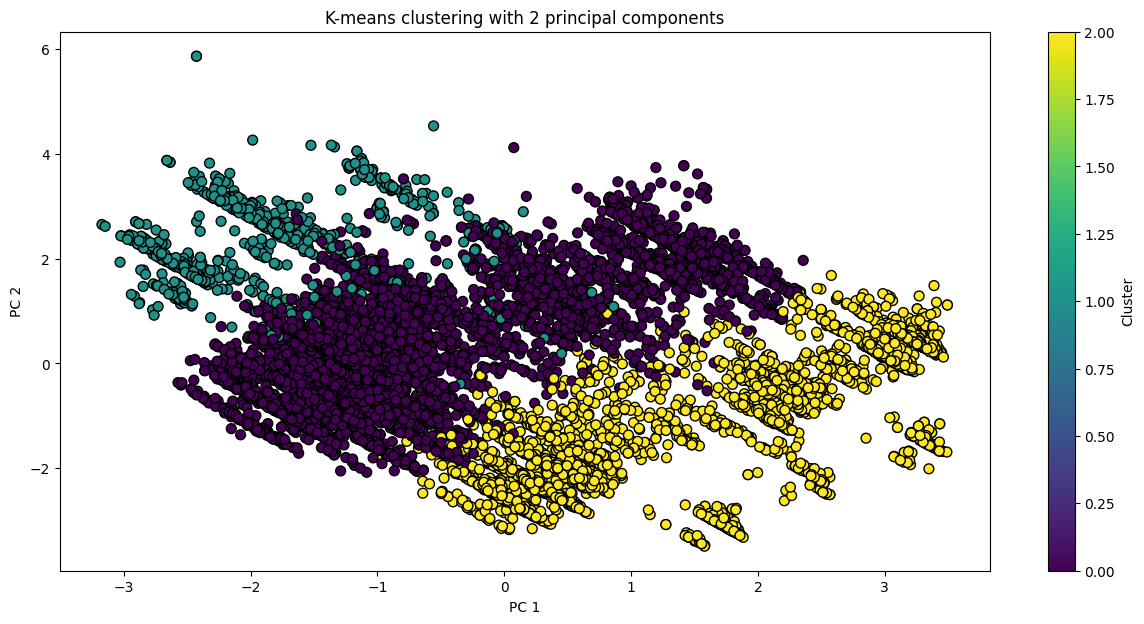

In [21]:
scaler = StandardScaler()
normalized_data = scaler.fit_transform(df_dummies)

kmeans_algo = KMeans(n_clusters=3, random_state=42)
clusters = kmeans_algo.fit_predict(normalized_data)

pca = PCA(n_components=2)
pca_data = pca.fit_transform(normalized_data)

# Plotting
plt.figure(figsize=(15, 7))
plt.scatter(pca_data[:,0], pca_data[:,1], c=clusters, cmap='viridis', edgecolor='k', s=50)
plt.title("K-means clustering with 2 principal components")
plt.xlabel("PC 1")
plt.ylabel("PC 2")
plt.colorbar(label='Cluster')
plt.show()

Os clusters não são claramente separáveis. Embora os pontos estejam maioritariamente agrupados por cluster, os grupos tocam-se nos seus limites, indicando uma sobreposição parcial. Isto implica que as componentes escolhidas para o PCA não captam totalmente as distinções entre todas as variáveis ou que existem semelhanças entre variáveis.

# c)

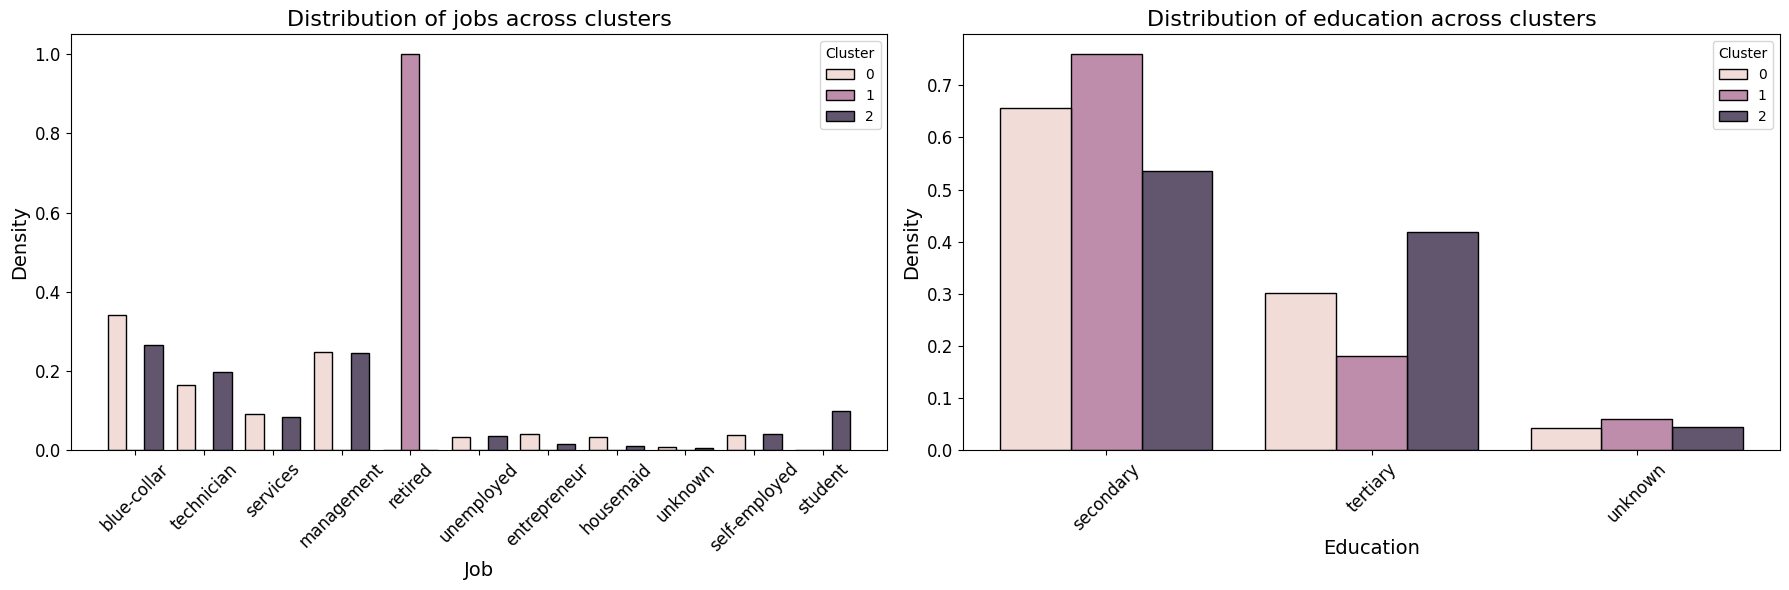

In [39]:
import seaborn as sns

df_dummies['Cluster'] = clusters

job_columns = [col for col in df_dummies.columns if col.startswith('job_')]
df_dummies['job'] = df_dummies[job_columns].idxmax(axis=1).str.replace('job_', '')

education_columns = [col for col in df_dummies.columns if col.startswith('education_')]
df_dummies['education'] = df_dummies[education_columns].idxmax(axis=1).str.replace('education_', '')

# Plotting
plt.figure(figsize=(18, 6))

plt.subplot(1, 2, 1)
sns.histplot(data=df_dummies, x='job', hue='Cluster', multiple="dodge", stat='density', 
             shrink=0.8, common_norm=False)
plt.title("Distribution of jobs across clusters", fontsize=16)
plt.xlabel("Job", fontsize=14)
plt.ylabel("Density", fontsize=14)
plt.xticks(rotation=45, fontsize=12)
plt.yticks(fontsize=12)

plt.subplot(1, 2, 2)
sns.histplot(data=df_dummies, x='education', hue='Cluster', multiple="dodge", stat='density', 
             shrink=0.8, common_norm=False)
plt.title("Distribution of education across clusters", fontsize=16)
plt.xlabel("Education", fontsize=14)
plt.ylabel("Density", fontsize=14)
plt.xticks(rotation=45, fontsize=12)
plt.yticks(fontsize=12)

plt.tight_layout()
plt.show()

A análise dos clusters revela padrões distintos tanto nos tipos de emprego como na educação dos clientes.
Ao nível de emprego, o cluster 0 tem uma maior concentração de clientes em trabalhos mais práticos e de gestão, indicando um grupo com empregos mais estáveis mas, geralmente, com menor rendimento. O cluster 1 apenas contém clientes reformados, indicando uma média de idade bastante avançada e uma maior segurança de rendimento. O cluster 2 apresenta uma distribuição parecida à do cluster 0, mas inclui um maior número de clientes que são estudantes ou estão em cargos menos práticos, indicando, assim, um menor rendimento médio, uma maior instabilidade financeira e uma idade média mais reduzida.
Ao nível da educação, o cluster 0 apresenta uma maioria de clientes com o ensino secundário ou inferior, verificado pela distribuição de empregos que corresponde a maioritáriamente blue-collar jobs. O cluster 1 apresenta uma maior percentagem de clientes com ensino secundário mas menos com educação superior, sugerindo clientes com maior idade, demografia esta com menor difusão de ensino superior. O cluster 2 um número significativo de clientes com ensino superior, concordante com o maior número de estudantes.
Resumindo, o cluster 0 é caracterizado por uma maior estabilidade no emprego e educação, o cluster 1 é marcado por uma totalidade de clientes reformados e o Cluster 2 representa uma tendência para clientes mais jovens.